# S.1 Supplementary material: frazil ice concentration error propagation and simulation

In [1]:
# FIC analysis simulation — Python version (NumPy, pandas, xarray, matplotlib)
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# Reproducibility
# ---------------------------------------
rng = np.random.default_rng(seed=100)  # Equivalent to R's set.seed(100)

# ---------------------------------------
# Camera set-up
# ---------------------------------------
l1 = 0.05 # increase assumed depth of field to account for more uncertainty
l2 = 2.95
# l1 = 0.4
# l2 = 1.12
l = (l1 + l2) / 2

N = 10000


# 1. Uncertainty in Frazil Ice Crystal Diameter

Images are projected onto a plane at distance $l$ (m) from the camera. The sampled water column spans $l_1=l-\tfrac{1}{2}\mathrm{DoF}$ and $l_2=l+\tfrac{1}{2}\mathrm{DoF}$, where $l$ is the focal distance and DoF is the depth of field (Fig. 5). A crystal at distance $x\in[l_1,l_2]$ has apparent diameter $D_{\mathrm{app}}$ related to true diameter $D$ by $D_{\mathrm{app}}=D\,\tfrac{l}{x}$, hence $D=\tfrac{x}{l}D_{\mathrm{app}}$.

## 1.1 Propagation of diameter uncertainty

$$
\frac{\Delta D}{D}=\frac{\Delta x}{x}+\frac{\Delta D_{\mathrm{app}}}{D_{\mathrm{app}}}
$$

Our analysis targets mean crystal diameter across an image stack ($n\approx10^4$). For the mean over $n$ crystals:

$$
\frac{\Delta\mathrm{mean}(D)}{\mathrm{mean}(D)}=\frac{1}{\sqrt{n}}\frac{\Delta D}{D}
$$

## 1.2 Combined uncertainty for the mean diameter

With $\Delta x=\tfrac{1}{2}(l_2-l_1)$:

$$
\frac{\Delta\mathrm{mean}(D)}{\mathrm{mean}(D)}=\frac{1}{\sqrt{n}}\left[\frac{1}{2}\frac{l_2-l_1}{l}+\frac{\sigma_1}{D_{\mathrm{app}}}+\frac{\epsilon_{w,\mathrm{frame}}}{\bar{w}_{\mathrm{frame}}}\right]
$$

Here, $\sigma_1$ is the segmentation uncertainty (0.5 px scaled by 1.3 mm px$^{-1}$), $\epsilon_{w,\mathrm{frame}}$ is the frame‑width uncertainty (m), and $\bar{w}_{\mathrm{frame}}$ is the estimated physical frame width (Table 1).


In [2]:
from IPython.display import display, Markdown
sigma1 = 1.3*1e-3*0.5
D_app = 3e-3 # m
n = N
epsilon_w_frame = 0.2 # m
w_frame_bar = 2.5 # m

rel_error_size_x = 0.5*(l2-l1)/l / np.sqrt(n)
rel_error_size_Dapp = sigma1 / D_app / np.sqrt(n)
rel_error_size_scale = epsilon_w_frame / w_frame_bar / np.sqrt(n)
rel_error_size = np.sqrt(rel_error_size_x**2+rel_error_size_Dapp**2+ rel_error_size_scale**2)

display(Markdown(f"""
We assume that $D_{{app}}$ = 3 mm, because the optical images showed large crystals and a previous study reported large suspended crystals at a site nearby (Stevens et al. 2023).

For a single crystal the relative error contributions then become:

- Geometric factor: $\\approx {100*rel_error_size_x:.2f}$ %
- Crystal edge uncertainty: $\\approx {100*rel_error_size_Dapp:.2f}$ %
- Scaling uncertainty due to auto-focus: ${100*rel_error_size_scale:.2f}$ %

The geometric factor is the dominant error. Error propagation then gives the total relative error:

$\\frac{{\Delta D}}{{D}} \\approx {100*rel_error_size:.2f}$ %
"""))

<>:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_2458850/3455606751.py:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  """))



We assume that $D_{app}$ = 3 mm, because the optical images showed large crystals and a previous study reported large suspended crystals at a site nearby (Stevens et al. 2023).

For a single crystal the relative error contributions then become:

- Geometric factor: $\approx 0.97$ %
- Crystal edge uncertainty: $\approx 0.22$ %
- Scaling uncertainty due to auto-focus: $0.08$ %

The geometric factor is the dominant error. Error propagation then gives the total relative error:

$\frac{\Delta D}{D} \approx 0.99$ %



# 2. Uncertainty in Frazil Ice Crystal Volume

## 2.1 Volume of an individual crystal

$$
V=\frac{D^3}{\tau}
$$

with aspect ratio $\tau=37\pm11$ (McFarlane et al., 2014).

## 2.2 Propagation of uncertainty in $x$, $D_{\mathrm{app}}$, and $\tau$

Express volume as:

$$
V=\frac{x^3D_{\mathrm{app}}^3}{l^3\tau}
$$

Log‑differentiation:

$$
\ln V=3\ln x+3\ln D_{\mathrm{app}}-3\ln l-\ln\tau
$$

Differential form (independent variables):

$$
\frac{\partial V}{V}=3\frac{\partial x}{x}+3\frac{\partial D_{\mathrm{app}}}{D_{\mathrm{app}}}-\frac{\partial\tau}{\tau}
$$

Propagated relative uncertainty:

$$
\frac{\Delta V}{V}\approx3\frac{\Delta x}{x}+3\frac{\Delta D_{\mathrm{app}}}{D_{\mathrm{app}}}+\frac{\Delta\tau}{\tau}
$$

With $\Delta x=\tfrac{1}{2}(l_2-l_1)$:

$$
\frac{\Delta V}{V}\approx\frac{3}{2}\frac{l_2-l_1}{l}+3\frac{\sigma_1}{D_{\mathrm{app}}}+\frac{\sigma_2}{\tau}
$$

where $\sigma_2=11$ is the uncertainty in $\tau$.



# 3. Uncertainty in Total Frazil Ice Volume

Total volume:

$$
V_{\mathrm{tot}}=\sum_{i=1}^{n}V_i
$$

Combined uncertainty (independent $V_i$):

$$
\Delta V_{\mathrm{tot}}=\sqrt{\sum_{i=1}^{n}(\Delta V_i)^2}
$$

Relative form:

$$
\frac{\Delta V_{\mathrm{tot}}}{V_{\mathrm{tot}}}=\frac{1}{\sqrt{n}}\frac{\Delta V}{V}
$$

Frazil‑ice concentration (FIC) uncertainty:

$$
\frac{\Delta\mathrm{FIC}}{\mathrm{FIC}}=\frac{\Delta V_{\mathrm{tot}}}{V_{\mathrm{tot}}}
$$


In [3]:
sigma2 = 11
tau = 37
from scipy.integrate import quad
# Compute each contribution
# Define the interval
x1, x2 = l1, l2

# Define the unnormalized probability density function
def p(x):
    return x**2

# Compute the normalization constant
normalization_constant, _ = quad(p, x1, x2)

# Define the normalized probability density function
def p_normalized(x):
    return p(x) / normalization_constant

# Compute the mean of x
def mean_x():
    integrand = lambda x: x * p_normalized(x)
    mean, _ = quad(integrand, x1, x2)
    return mean

# Compute the standard deviation of x
def std_x(mean):
    integrand = lambda x: ((x - mean)**2) * p_normalized(x)
    variance, _ = quad(integrand, x1, x2)
    return np.sqrt(variance)

# Calculate mean and standard deviation
mean = mean_x()
std = std_x(mean)

rel_error_geom = 3 * std/mean / np.sqrt(n)
rel_error_thresh = 3 * (sigma1 / D_app) / np.sqrt(n)
rel_error_tau = sigma2 / tau / np.sqrt(n)
rel_error = np.sqrt(rel_error_geom**2 + rel_error_thresh**2 + rel_error_tau**2)
rel_error_total = rel_error
rel_error_total_mgL = rel_error_total

display(Markdown(f"""
Relative error contributions:

- Geometric factor: $\\approx {100*rel_error_geom:.2f}$ %
- Crystal edge uncertainty: $\\approx {100*rel_error_thresh:.2f}$ %
- Aspect ratio factor: $\\approx {100*rel_error_tau:.2f}$ %

Combined (used here): 

$\\frac{{\\Delta V_{{tot}}}}{{V_{{tot}}}} \\approx {100*rel_error:.2f}$ %

Indicating that uncertainty in $x$ is likely the dominant error term.
"""))



Relative error contributions:

- Geometric factor: $\approx 0.77$ %
- Crystal edge uncertainty: $\approx 0.65$ %
- Aspect ratio factor: $\approx 0.30$ %

Combined (used here): 

$\frac{\Delta V_{tot}}{V_{tot}} \approx 1.05$ %

Indicating that uncertainty in $x$ is likely the dominant error term.


# 3. Simulations

## a) Geometry moments (x $\propto$ x$^2$ on [l$_1$, l$_2$])

With density $f(x)=\frac{3x^2}{l_2^3-l_1^3}$ on $[l_1,l_2]$, the analytical moments used to debias foreshortening are:
$$
\mu_1 = \mathbb{E}[x] = \frac{3\,(l_2^4 - l_1^4)}{4\,(l_2^3 - l_1^3)},\quad
\mu_2 = \mathbb{E}[x^2] = \frac{3\,(l_2^5 - l_1^5)}{5\,(l_2^3 - l_1^3)}
$$
$$
\mu_{-1} = \mathbb{E}\!\left[\frac{1}{x}\right] = \frac{3\,(l_2^2 - l_1^2)}{2\,(l_2^3 - l_1^3)},\quad
\mu_{-3} = \mathbb{E}\!\left[\frac{1}{x^3}\right] = \frac{3\,(\ln l_2 - \ln l_1)}{(l_2^3 - l_1^3)}
$$

## b) Frazil‑ice setup & estimators

Parameters (constants in the simulation): mean diameter ($\mu_d$=1 mm; Frazer et al. 2020), ($\sigma_d$=0.5), ice density ($\rho_i$=917 kg m$^{-3}$), frames ($N_{\text{frames}}$=1400), base ($w$=2.5 m, $h$=1.4 m), masks ($w_{\text{mask}}$=0.728, $h_{\text{mask}}$=0.793), depth‑of‑field ($l$=DoF=0.11 m).  
Field‑of‑view volume per frame (frustum difference):
$$
V_{\text{frame}}=\frac{w\,h\,l}{3}-\frac{w_{\text{mask}}\,h_{\text{mask}}\,l}{3}
$$

**Simulation (per trial):** sample locations $x$ via inverse‑CDF of $x^3$ on $[l_1,l_2]$; draw actual diameters $d_i\sim \mathcal{N}(\mu_d,\sigma_d)$ (lognormal alternative optional); volumes $V_i=d_i^3$. Apparent diameters/volumes from geometry:
$$
d = d_i\,\frac{l}{x},\qquad V = d^3
$$

**Unbiased estimators (geometry‑corrected):**
$$
\hat{D}=\frac{\overline{d}}{\mu_{-1}\,l},\qquad
\hat{V}=\frac{\overline{V}}{\mu_{-3}\,l^3}
$$


### **Uncertainty due to crystal location**

To quantify the bias introduced purely by the crystals’ positions within the depth‑of‑field, we compare the true (sampled) means with their geometry‑corrected estimates:

**Diameter error**
$$
\frac{\delta_{sys}D}{D} \approx \bigl|\,\mathrm{mean}(d_i)\;-\;\hat{D}\,\bigr|
$$

**Volume error**
$$
\frac{\delta_{sys}V}{V}  \approx \bigl|\,\mathrm{mean}(V_i)\;-\;\hat{V}\,\bigr|
$$

These error estimates capture the bias due to the analytic moments using reasonable assumptions for $l_1$ and $l_2$ (Taylor 1982, 4.6).

mean(dD/dM) = 0.237504
sd(dD/dM)   = 0.000000
mean(dV/VM) = 0.608159
sd(dV/VM)   = 0.000000
mean(dM) = 1.001315
sd(dM)   = 0.009254
mean(VM) = 1.746753
sd(VM)   = 0.905229

Pandas results head:
    trial        dM        VM
0      1  1.002782  8.213662
1      2  1.007602  2.627861
2      3  0.997066  1.407553
3      4  0.999676  1.509435
4      5  0.997866  1.417008 



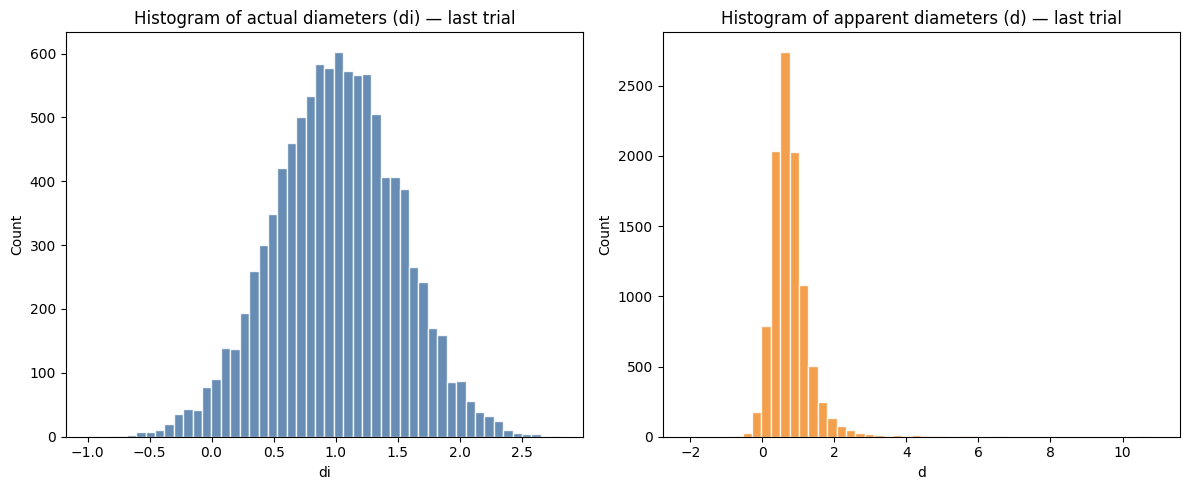

In [6]:
# ---------------------------------------
# Frazil ice details — number and diameter
# ---------------------------------------
mu_d = 1. # from data, uncertain due to auto-focus!
sig_d = 0.5
m = -7.8 + np.log(1000)
s = 1.3
Rhoi = 917 # kg/m3
N_frames = 1400
w = 2.5 # base width m
h = 1.4 # base length m
w_mask = 0.728 # masked pixels due to brick removal
h_mask = 0.793 # masked pixels due to brick removal
DoF = 0.11 # m
V_frame = (w * h * l)/3 - (w_mask * h_mask * l)/3

mu_1 = 3 * (l2**4 - l1**4) / (4 * (l2**3 - l1**3))
mu_2 = 3 * (l2**5 - l1**5) / (5 * (l2**3 - l1**3))
mu_neg1 = 3 * (l2**2 - l1**2) / (2 * (l2**3 - l1**3))
mu_neg3 = 3 * (np.log(l2) - np.log(l1)) / (l2**3 - l1**3)

M = 100  # number of trials

# Storage for per-trial estimators
dM = np.empty(M)  # mean diameter estimator
VM = np.empty(M)  # mean volume estimator
dD = np.empty(M)  # mean diameter error estimator
dV = np.empty(M)  # mean volume error estimator

# To mimic R's hist(di); hist(d), we keep the last trial's di and d
last_di = None
last_d = None

# ---------------------------------------
# Simulation loop
# ---------------------------------------
for m in range(M):
    # locations (x) distributed with density proportional to x^2 over [l1, l2]
    # implemented via inverse CDF for x^3
    x = (l1**3 + (l2**3 - l1**3) * rng.random(N)) ** (1/3)

    # actual diameter and volume
    di = rng.normal(loc=mu_d, scale=sig_d, size=N)
    # di = rng.lognormal(mean = m, sigma = s, size = N)
    # di = di[di>0]
    Vi = di**3

    # apparent diameter and volume (geometry transform)
    d = di * l / x
    V = d**3

    # estimators (same normalization as in R)
    dM[m] = np.mean(d) / (mu_neg1 * l)
    VM[m] = np.mean(V) / (mu_neg3 * l**3)

    dD[m] = np.abs(np.mean(d)-dM[m])
    dV[m] = np.abs(np.mean(V)-VM[m])

    # store last trial data for histograms
    last_di = di
    last_d = d

# Per-trial relative inaccuracies (ratios), matching your original definitions
rel_inacc_D = dD / dM   # dD/dM
rel_inacc_V = dV / VM   # dV/VM

print(f"mean(dD/dM) = {np.nanmean(rel_inacc_D):.6f}")
print(f"sd(dD/dM)   = {np.nanstd(rel_inacc_D, ddof=1):.6f}")
print(f"mean(dV/VM) = {np.nanmean(rel_inacc_V):.6f}")
print(f"sd(dV/VM)   = {np.nanstd(rel_inacc_V, ddof=1):.6f}")

# ---------------------------------------
# Summary stats
# ---------------------------------------
dM_mean = np.mean(dM)
dM_sd = np.std(dM, ddof=1)  # sample std dev

VM_mean = np.mean(VM)
VM_sd = np.std(VM, ddof=1)
VM_sd_m3 = VM_sd*1e-9
VM_mean_m3 = VM_mean*1e-9

print(f"mean(dM) = {dM_mean:.6f}")
print(f"sd(dM)   = {dM_sd:.6f}")
print(f"mean(VM) = {VM_mean:.6f}")
print(f"sd(VM)   = {VM_sd:.6f}")

# ---------------------------------------
# Store results with pandas and xarray
# ---------------------------------------
df_results = pd.DataFrame({
    "trial": np.arange(1, M+1),
    "dM": dM,
    "VM": VM
})

# xarray Dataset (nice for labeled multi-dim data)
ds = xr.Dataset(
    {
        "dM": (("trial",), dM),
        "VM": (("trial",), VM),
    },
    coords={"trial": np.arange(1, M+1)}
)

# Optional: show quick summary
print("\nPandas results head:\n", df_results.head(), "\n")

# ---------------------------------------
# Histograms (using last trial di and d)
# ---------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(last_di, bins=50, color="#4e79a7", alpha=0.85, edgecolor="white")
plt.title("Histogram of actual diameters (di) — last trial")
plt.xlabel("di")
plt.ylabel("Count")
# plt.xscale("log")

plt.subplot(1, 2, 2)
plt.hist(last_d, bins=50, color="#f28e2b", alpha=0.85, edgecolor="white")
plt.title("Histogram of apparent diameters (d) — last trial")
plt.xlabel("d")
plt.ylabel("Count")
# plt.xscale("log")

plt.tight_layout()
plt.show()

rel_uncertainty_D_mean_prop_sim = np.sqrt((np.mean(dD)/dM_mean)**2 + rel_error_size**2)
rel_uncertainty_V_mean_prop_sim = np.sqrt((np.mean(dV)/VM_mean)**2 + rel_error_total**2)

rel_error_D_mean_prop_sim = np.sqrt((dM_sd/dM_mean)**2 + rel_error_size**2)
rel_error_V_mean_prop_sim = np.sqrt((VM_sd/VM_mean)**2 + rel_error_total**2)

# 3. Final errors for mean diameter and frazil ice concentration

## a) mean diameter
We add the errors due to unknown positioning (from the simulations), the crystal edge uncertainty and the scaling uncertainty in quadrature.

$\frac{\Delta D}{D}
=
\sqrt{
  \left( \frac{\delta_{sys}D}{D} \right)^2
  +
  \left( \frac{1}{\sqrt{n}} \frac{\sigma_1}{D_{\mathrm{app}}} \right)^2
  +
  \left( \frac{1}{\sqrt{n}} \frac{\epsilon_{w,\mathrm{frame}}}{\bar{w}_{\mathrm{frame}}} \right)^2
}$

where $\hat{D}$ the estimated true diameter based on the analytic moments.

## b) frazil ice concentration
We add the errors due to unknown positioning (from the simulations), the crystal edge uncertainty and the diameter-to-thickness ratio uncertainty in quadrature.
$\frac{\Delta FIC}{FIC} = 
\sqrt{
\left( \frac{\delta_{sys}V}{V} \right)^2
+ \left( \frac{3}{\sqrt{n}} \cdot \frac{\sigma_1}{D_{\text{app}}} \right)^2
+ \left( \frac{1}{\sqrt{n}} \cdot \frac{\sigma_2}{\tau} \right)^2}$
 
where $\hat{V}$ the estimated true ice volumes based on the analytic moments.

In [10]:
icefin_10m =  f"{3.4e-5 * rel_error_V_mean_prop_sim:.2e}"
icefin_20m =  f"{8.9e-8 * rel_error_V_mean_prop_sim:.2e}"

display(Markdown(f"""
We applied this relative error to the results reported in Figure 9. For example, the FIC was $3.4 \\times 10^{{-5}}$ m³/m³ at 10 m depth, and $8.9 \\times 10^{{-8}}$ m³/m³ at 20 m depth. Multiplication with the relative error in mean crystal volume yielded:

* $FIC = 3.4 \\times 10^{{-5}} \\pm {icefin_10m}$ m³/m³ for 10 m depth  
* $FIC = 8.9 \\times 10^{{-8}} \\pm {icefin_20m}$ m³/m³ for 20 m depth

"""))


We applied this relative error to the results reported in Figure 9. For example, the FIC was $3.4 \times 10^{-5}$ m³/m³ at 10 m depth, and $8.9 \times 10^{-8}$ m³/m³ at 20 m depth. Multiplication with the relative error in mean crystal volume yielded:

* $FIC = 3.4 \times 10^{-5} \pm 1.76e-05$ m³/m³ for 10 m depth  
* $FIC = 8.9 \times 10^{-8} \pm 4.61e-08$ m³/m³ for 20 m depth

